# Modelo de Riesgo Crediticio – Análisis Estadístico Completo
**Dataset:** German Credit Risk &nbsp;|&nbsp; **Variable objetivo:** `Risk` (0 = bajo riesgo, 1 = alto riesgo)

In [29]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, pointbiserialr
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_selection import SelectKBest, chi2, f_classif
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
PALETTE = ['#2166ac', '#d73027']
np.random.seed(42)


In [30]:
df = pd.read_csv('datos.csv', index_col=0)

# Orden cardinal de variables ordinales
sav_order = ['no tiene', 'little', 'moderate', 'quite rich', 'rich']
chk_order = ['no tiene', 'little', 'moderate', 'rich']

df['sav_num'] = df['Saving.accounts'].map({v: i+1 for i, v in enumerate(sav_order)})
df['chk_num'] = df['Checking.account'].map({v: i+1 for i, v in enumerate(chk_order)})
df['sex_bin'] = (df['Sex'] == 'male').astype(int)

hous_map = {'free': 0, 'rent': 1, 'own': 2}
df['hous_num'] = df['Housing'].map(hous_map)

df['log_credit'] = np.log1p(df['Credit.amount'])

print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()


Dimensiones: 1000 filas × 15 columnas


,Age,Sex,Job,Housing,Saving.accounts,Checking.account,Credit.amount,Duration,Purpose,Risk,sav_num,chk_num,sex_bin,hous_num,log_credit
X,,,,,,,,,,,,,,,
0,67,male,2,own,no tiene,little,1169,6,radio/TV,0,1,2,1,2,7.064759
1,22,female,2,own,little,moderate,5951,48,radio/TV,1,2,3,0,2,8.691483
2,49,male,1,own,little,no tiene,2096,12,education,0,2,1,1,2,7.648263
3,45,male,2,free,little,little,7882,42,furniture/equipment,0,2,2,1,0,8.972464
4,53,male,2,free,little,little,4870,24,car,1,2,2,1,0,8.491055


In [31]:
print("=== TIPOS Y NULOS ===")
print(df.dtypes.to_string())
print(f"\nValores nulos:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


=== TIPOS Y NULOS ===
Age                   int64
Sex                  object
Job                   int64
Housing              object
Saving.accounts      object
Checking.account     object
Credit.amount         int64
Duration              int64
Purpose              object
Risk                  int64
sav_num               int64
chk_num               int64
sex_bin               int64
hous_num              int64
log_credit          float64

Valores nulos:
Series([], dtype: int64)


In [32]:
num_cols = ['Age', 'Credit.amount', 'Duration', 'Job', 'sav_num', 'chk_num']
df[num_cols + ['Risk']].describe(percentiles=[.25, .5, .75]).round(2)


,Age,Credit.amount,Duration,Job,sav_num,chk_num,Risk
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,35.55,3271.26,20.90,1.90,2.19,2.00,0.30
std,11.38,2822.74,12.06,0.65,0.97,0.96,0.46
min,19.00,250.00,4.00,0.00,1.00,1.00,0.00
25%,27.00,1365.50,12.00,2.00,2.00,1.00,0.00
50%,33.00,2319.50,18.00,2.00,2.00,2.00,0.00
75%,42.00,3972.25,24.00,2.00,2.00,3.00,1.00
max,75.00,18424.00,72.00,3.00,5.00,4.00,1.00


In [33]:
vc = df['Risk'].value_counts()
print("Distribución de Risk:")
print(pd.DataFrame({'N': vc, '%': (vc / len(df) * 100).round(2)}))


Distribución de Risk:
        N     %
Risk           
0     700  70.0
1     300  30.0


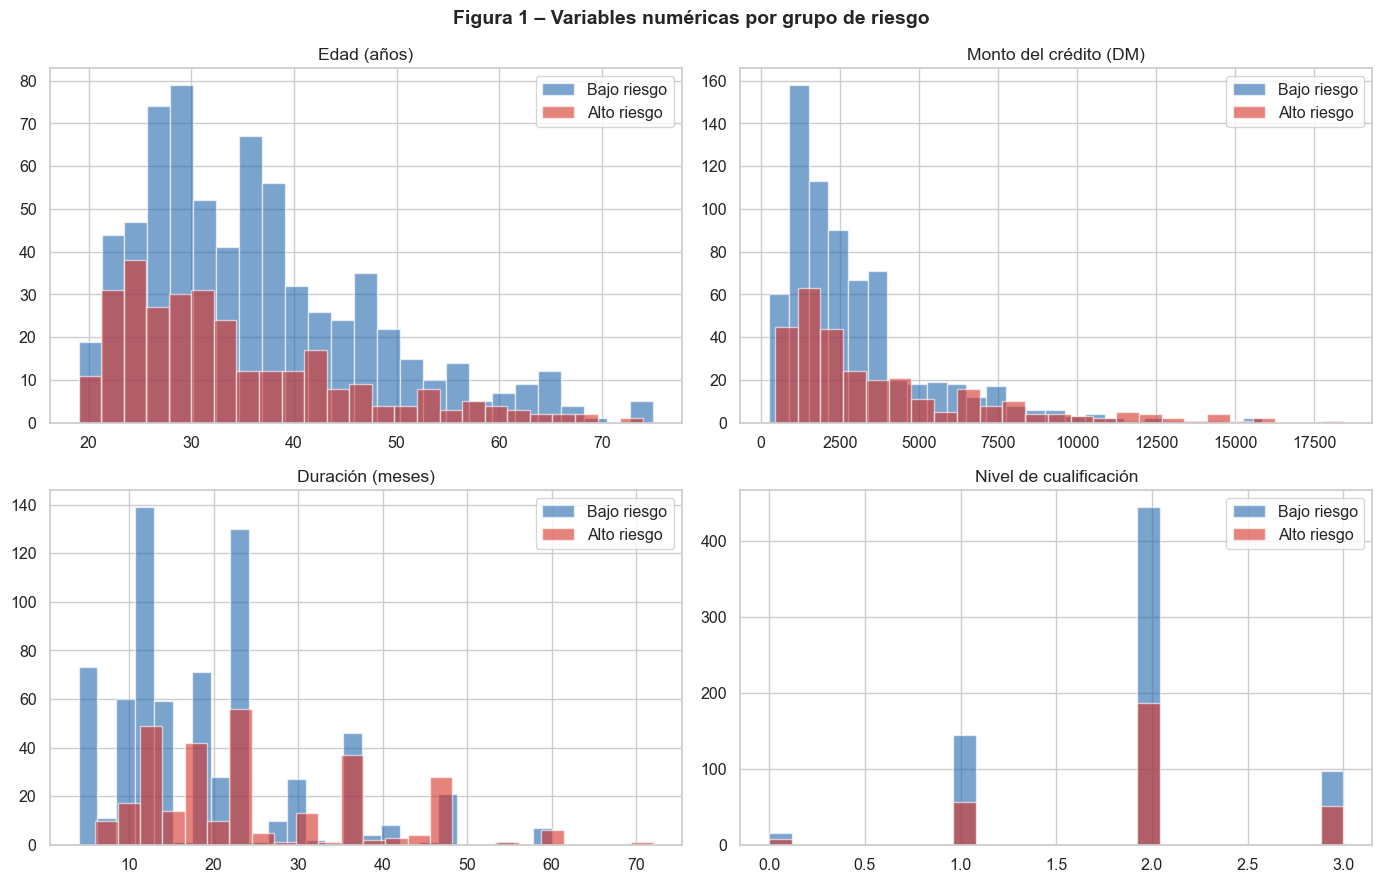

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Figura 1 – Variables numéricas por grupo de riesgo', fontsize=14, fontweight='bold')

vars_plot = [
    ('Age',           'Edad (años)'),
    ('Credit.amount', 'Monto del crédito (DM)'),
    ('Duration',      'Duración (meses)'),
    ('Job',           'Nivel de cualificación'),
]
labels = ['Bajo riesgo', 'Alto riesgo']

for ax, (col, title) in zip(axes.flat, vars_plot):
    for risk_val, color, label in zip([0, 1], PALETTE, labels):
        ax.hist(df.loc[df['Risk'] == risk_val, col],
                bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    ax.set_title(title); ax.set_xlabel(''); ax.legend()

plt.tight_layout()
plt.savefig('fig1_numericas.png', dpi=150, bbox_inches='tight')
plt.show()


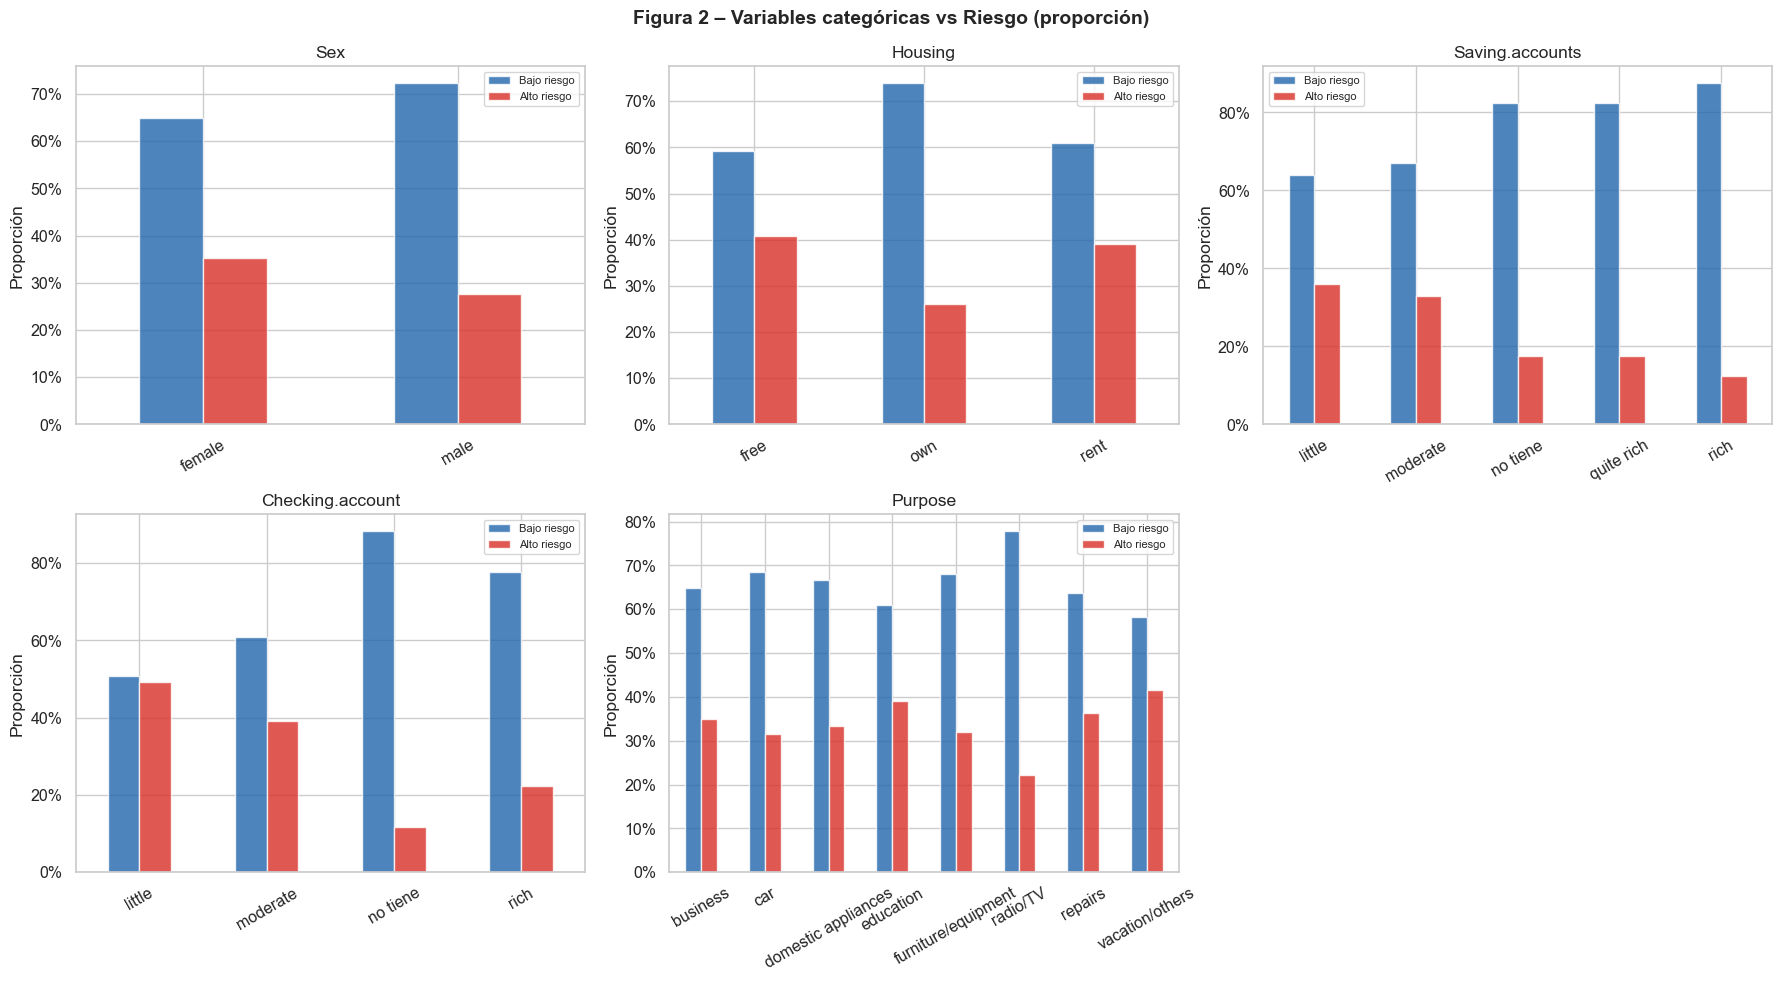

In [35]:
cat_cols = ['Sex', 'Housing', 'Saving.accounts', 'Checking.account', 'Purpose']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figura 2 – Variables categóricas vs Riesgo (proporción)', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, cat_cols):
    ct = pd.crosstab(df[col], df['Risk'], normalize='index')
    ct.columns = ['Bajo riesgo', 'Alto riesgo']
    ct.plot(kind='bar', ax=ax, color=PALETTE, alpha=0.8, edgecolor='white')
    ax.set_title(col); ax.set_ylabel('Proporción'); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30); ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()


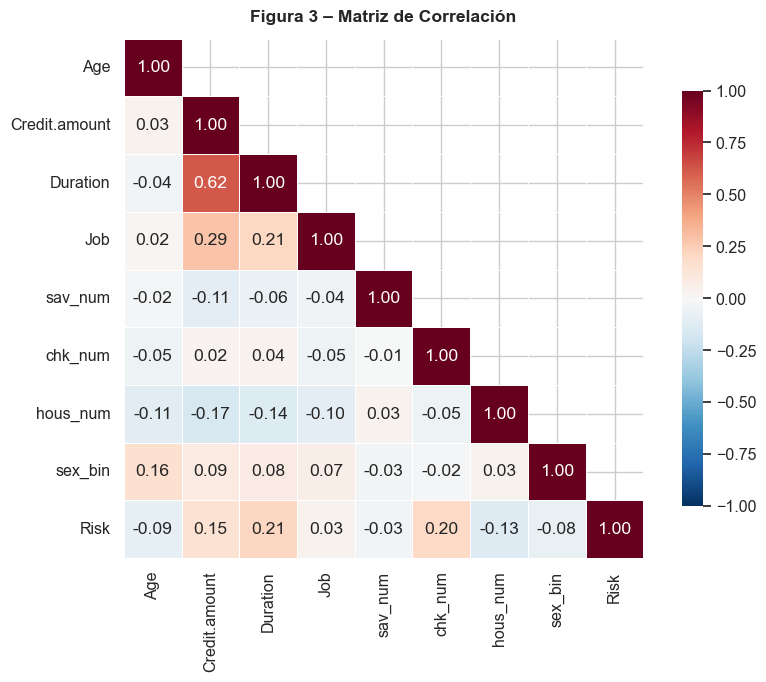

In [36]:
cor_cols = ['Age', 'Credit.amount', 'Duration', 'Job',
             'sav_num', 'chk_num', 'hous_num', 'sex_bin', 'Risk']
corr = df[cor_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=.5, ax=ax, cbar_kws={'shrink': .8})
ax.set_title('Figura 3 – Matriz de Correlación', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig3_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()


In [37]:
print("=== Chi² – Variables categóricas vs Risk ===")
print(f"{'Variable':<25} {'Chi2':>8} {'p-valor':>10}  Decisión")
print("-" * 60)
for col in ['Sex', 'Housing', 'Saving.accounts', 'Checking.account', 'Purpose']:
    ct = pd.crosstab(df[col], df['Risk'])
    chi2_stat, p, _, _ = chi2_contingency(ct)
    dec = 'Asociada *' if p < 0.05 else 'No asociada'
    print(f"  {col:<23} {chi2_stat:>8.3f} {p:>10.4f}  {dec}")

print("\n=== t-test – Variables numéricas por grupo de Risk ===")
print(f"{'Variable':<20} {'Media(R=0)':>12} {'Media(R=1)':>12} {'p-valor':>10}  Decisión")
print("-" * 68)
for col in ['Age', 'Credit.amount', 'Duration', 'sav_num', 'chk_num']:
    g0 = df.loc[df['Risk']==0, col].dropna()
    g1 = df.loc[df['Risk']==1, col].dropna()
    t_stat, p = ttest_ind(g0, g1)
    dec = 'Diferente *' if p < 0.05 else 'No diferente'
    print(f"  {col:<18} {g0.mean():>12.2f} {g1.mean():>12.2f} {p:>10.4f}  {dec}")


=== Chi² – Variables categóricas vs Risk ===
Variable                      Chi2    p-valor  Decisión
------------------------------------------------------------
  Sex                        5.349     0.0207  Asociada *
  Housing                   18.200     0.0001  Asociada *
  Saving.accounts           36.099     0.0000  Asociada *
  Checking.account         123.721     0.0000  Asociada *
  Purpose                   13.642     0.0579  No asociada

=== t-test – Variables numéricas por grupo de Risk ===
Variable               Media(R=0)   Media(R=1)    p-valor  Decisión
--------------------------------------------------------------------
  Age                       36.22        33.96     0.0039  Diferente *
  Credit.amount           2985.46      3938.13     0.0000  Diferente *
  Duration                  19.21        24.86     0.0000  Diferente *
  sav_num                    2.21         2.14     0.2846  No diferente
  chk_num                    1.88         2.29     0.0000  Diferente 

In [38]:
print("=== Correlación Punto-Biserial con Risk ===")
print(f"{'Variable':<22} {'r':>8} {'p-valor':>10}")
print("-" * 44)
for col in ['Age', 'Credit.amount', 'Duration', 'Job',
            'sav_num', 'chk_num', 'hous_num', 'sex_bin']:
    r, p = pointbiserialr(df['Risk'], df[col].fillna(df[col].median()))
    print(f"  {col:<20} {r:>8.4f} {p:>10.4f}  {'*' if p<0.05 else ''}")


=== Correlación Punto-Biserial con Risk ===
Variable                      r    p-valor
--------------------------------------------
  Age                   -0.0911     0.0039  *
  Credit.amount          0.1547     0.0000  *
  Duration               0.2149     0.0000  *
  Job                    0.0327     0.3011  
  sav_num               -0.0339     0.2846  
  chk_num                0.1978     0.0000  *
  hous_num              -0.1278     0.0001  *
  sex_bin               -0.0755     0.0170  *


In [39]:
purpose_dummies = pd.get_dummies(df['Purpose'], prefix='purp', drop_first=True)
df_model = pd.concat([
    df[['Age', 'Credit.amount', 'Duration', 'Job',
        'sav_num', 'chk_num', 'hous_num', 'sex_bin', 'Risk']],
    purpose_dummies
], axis=1).dropna()

# Forzar todo a float desde el origen
df_model = df_model.astype(float)

feature_cols = [c for c in df_model.columns if c != 'Risk']
X_raw = df_model[feature_cols]
y     = df_model['Risk']

X_const = sm.add_constant(X_raw)
print(f"Matriz X: {X_raw.shape}  |  y: {y.shape}")

Matriz X: (1000, 15)  |  y: (1000,)


In [40]:
def backward_elimination(X, y, threshold=0.05):
    # Forzar dtype numérico para evitar error con columnas object/bool
    X = X.apply(pd.to_numeric, errors='coerce').astype(float)
    y = y.astype(float)
    cols = list(X.columns)
    while True:
        model = sm.OLS(y, X[cols]).fit()
        pvals = model.pvalues.drop('const', errors='ignore')
        max_p = pvals.max()
        if max_p > threshold:
            cols.remove(pvals.idxmax())
        else:
            break
    return cols, model

selected_cols, _ = backward_elimination(X_const, y)
selected_feats   = [c for c in selected_cols if c != 'const']
print("Variables seleccionadas por backward elimination (p < 0.05):")
print(selected_feats)


Variables seleccionadas por backward elimination (p < 0.05):
['Age', 'Duration', 'chk_num', 'hous_num', 'sex_bin', 'purp_radio/TV']


In [41]:
X_sel = df_model[selected_feats].apply(pd.to_numeric, errors='coerce').astype(float)
X_sel_const = sm.add_constant(X_sel)

mco = sm.OLS(y.astype(float), X_sel_const).fit(cov_type='HC3')
print(mco.summary())

                            OLS Regression Results                            
Dep. Variable:                   Risk   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     23.22
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           9.38e-26
Time:                        01:04:19   Log-Likelihood:                -580.03
No. Observations:                1000   AIC:                             1174.
Df Residuals:                     993   BIC:                             1208.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.2496      0.076      3.298

In [42]:
logit_model = sm.Logit(y, X_sel_const).fit(disp=False)
print(logit_model.summary())


                           Logit Regression Results                           
Dep. Variable:                   Risk   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      993
Method:                           MLE   Df Model:                            6
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                 0.09367
Time:                        01:04:19   Log-Likelihood:                -553.65
converged:                       True   LL-Null:                       -610.86
Covariance Type:            nonrobust   LLR p-value:                 2.400e-22
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.1030      0.393     -2.804      0.005      -1.874      -0.332
Age              -0.0187      0.007     -2.690      0.007      -0.032      -0.005
Duration          0.0367      0.006     

In [43]:
conf = logit_model.conf_int()
conf.columns = ['IC_2.5%', 'IC_97.5%']
or_df = pd.concat([
    np.exp(logit_model.params).rename('OR'),
    np.exp(conf)
], axis=1).round(3)
print("=== Odds Ratios (Logit) ===")
print(or_df)


=== Odds Ratios (Logit) ===
                  OR  IC_2.5%  IC_97.5%
const          0.332    0.154     0.718
Age            0.981    0.968     0.995
Duration       1.037    1.025     1.050
chk_num        1.570    1.351     1.824
hous_num       0.750    0.608     0.926
sex_bin        0.695    0.510     0.949
purp_radio/TV  0.591    0.419     0.834


In [44]:
r2        = mco.rsquared
r2_adj    = mco.rsquared_adj
pseudo_r2 = logit_model.prsquared
aic_mco   = mco.aic
aic_log   = logit_model.aic

print("=== Métricas de ajuste ===")
print(f"  R²  (MCO)                  : {r2:.4f}")
print(f"  R² ajustado (MCO)          : {r2_adj:.4f}")
print(f"  AIC (MCO)                  : {aic_mco:.2f}")
print(f"  AIC (Logit)                : {aic_log:.2f}")
print(f"  Pseudo R² McFadden (Logit) : {pseudo_r2:.4f}")
print(f"  Log-Likelihood (Logit)     : {logit_model.llf:.4f}")


=== Métricas de ajuste ===
  R²  (MCO)                  : 0.1106
  R² ajustado (MCO)          : 0.1052
  AIC (MCO)                  : 1174.06
  AIC (Logit)                : 1121.29
  Pseudo R² McFadden (Logit) : 0.0937
  Log-Likelihood (Logit)     : -553.6472


In [45]:
X_vif = sm.add_constant(
    df_model[selected_feats].apply(pd.to_numeric, errors='coerce').astype(float)
)
vif_data = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF'     : [variance_inflation_factor(X_vif.values, i)
                 for i in range(X_vif.shape[1])]
}).query("Variable != 'const'").sort_values('VIF', ascending=False)

print("=== Factores de Inflación de Varianza (VIF) ===")
print(vif_data.round(3).to_string(index=False))
flag = vif_data['VIF'].max()
print(f"\n{'⚠ VIF máximo > 10: posible multicolinealidad.' if flag>10 else '✓ Sin multicolinealidad grave (VIF < 10).'}")


=== Factores de Inflación de Varianza (VIF) ===
     Variable   VIF
     hous_num 1.059
          Age 1.050
      sex_bin 1.040
     Duration 1.033
purp_radio/TV 1.022
      chk_num 1.006

✓ Sin multicolinealidad grave (VIF < 10).


In [46]:
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(mco.resid, mco.model.exog)
print("=== Test de Breusch-Pagan (heterocedasticidad) ===")
print(f"  LM = {bp_lm:.4f}  |  p-valor = {bp_p:.4f}")
print("  → Heterocedasticidad presente (usar HC3)." if bp_p < 0.05
      else "  → No se detecta heterocedasticidad.")


=== Test de Breusch-Pagan (heterocedasticidad) ===
  LM = 98.9138  |  p-valor = 0.0000
  → Heterocedasticidad presente (usar HC3).


=== Distancias de Cook  (umbral = 4/n = 0.0040) ===
  Observaciones influyentes: 28


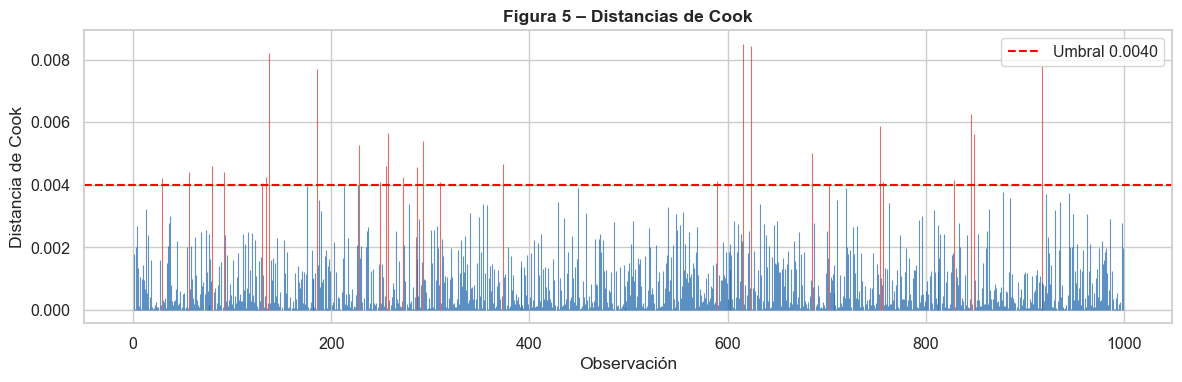

In [47]:
influence = mco.get_influence()
cooks_d   = influence.cooks_distance[0]
threshold = 4 / len(y)
outlier_idx = np.where(cooks_d > threshold)[0]

print(f"=== Distancias de Cook  (umbral = 4/n = {threshold:.4f}) ===")
print(f"  Observaciones influyentes: {len(outlier_idx)}")

fig, ax = plt.subplots(figsize=(12, 4))
colors = np.where(cooks_d > threshold, '#d73027', '#2166ac')
ax.vlines(range(len(cooks_d)), 0, cooks_d, colors=colors, linewidth=0.8, alpha=0.7)
ax.axhline(threshold, color='red', linestyle='--', linewidth=1.5, label=f'Umbral {threshold:.4f}')
ax.set_xlabel('Observación'); ax.set_ylabel("Distancia de Cook")
ax.set_title("Figura 5 – Distancias de Cook", fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('fig5_cooks.png', dpi=150, bbox_inches='tight')
plt.show()


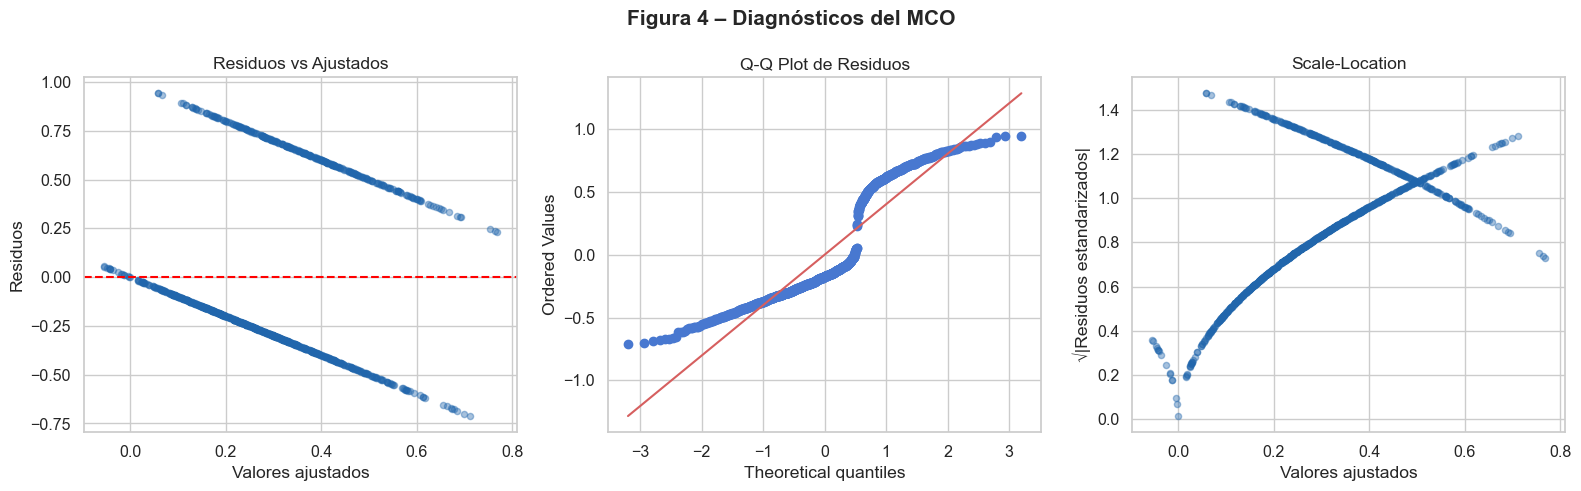

In [48]:
fitted_vals = mco.fittedvalues
residuals   = mco.resid
std_resid   = (residuals - residuals.mean()) / residuals.std()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figura 4 – Diagnósticos del MCO', fontweight='bold')

axes[0].scatter(fitted_vals, residuals, alpha=0.4, color='#2166ac', s=20)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores ajustados'); axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Ajustados')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot de Residuos')

axes[2].scatter(fitted_vals, np.sqrt(np.abs(std_resid)),
                alpha=0.4, color='#2166ac', s=20)
axes[2].set_xlabel('Valores ajustados'); axes[2].set_ylabel('√|Residuos estandarizados|')
axes[2].set_title('Scale-Location')

plt.tight_layout()
plt.savefig('fig4_diagnosticos_mco.png', dpi=150, bbox_inches='tight')
plt.show()


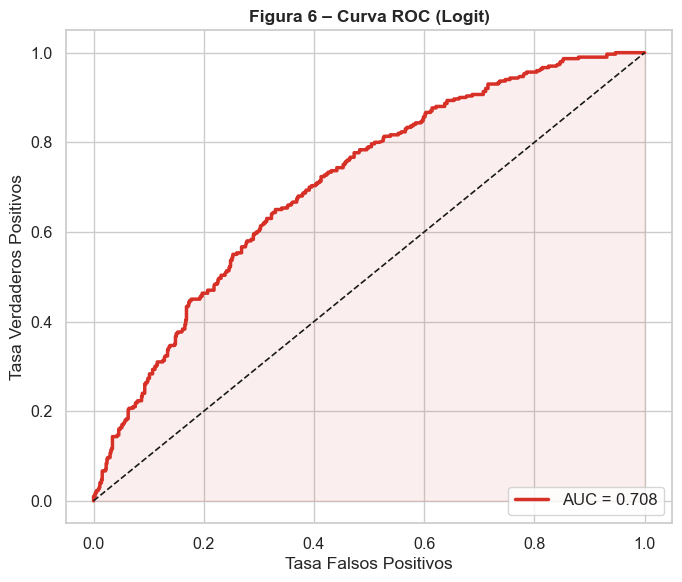

AUC = 0.7080


In [49]:
y_prob = logit_model.predict(X_sel_const)
fpr, tpr, thresholds = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#d73027', lw=2.5, label=f'AUC = {roc_auc:.3f}')
ax.plot([0,1], [0,1], 'k--', lw=1.2)
ax.fill_between(fpr, tpr, alpha=0.08, color='#d73027')
ax.set_xlabel('Tasa Falsos Positivos'); ax.set_ylabel('Tasa Verdaderos Positivos')
ax.set_title('Figura 6 – Curva ROC (Logit)', fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.savefig('fig6_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC = {roc_auc:.4f}")


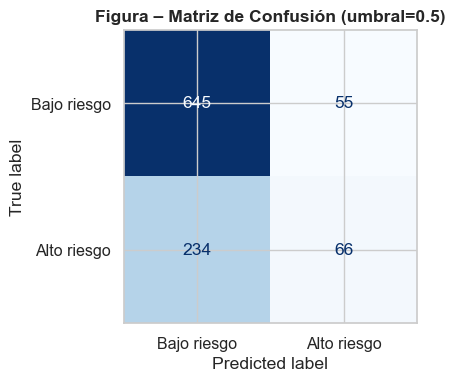

              precision    recall  f1-score   support

 Bajo riesgo       0.73      0.92      0.82       700
 Alto riesgo       0.55      0.22      0.31       300

    accuracy                           0.71      1000
   macro avg       0.64      0.57      0.57      1000
weighted avg       0.68      0.71      0.67      1000



In [50]:
y_pred = (y_prob >= 0.5).astype(int)
cm = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=['Bajo riesgo', 'Alto riesgo'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Figura – Matriz de Confusión (umbral=0.5)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y, y_pred, target_names=['Bajo riesgo', 'Alto riesgo']))


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logit',  LogisticRegression(max_iter=1000, random_state=42))
])

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_cv = df_model[selected_feats]

acc_cv  = cross_val_score(pipe, X_cv, y, cv=cv, scoring='accuracy')
auc_cv  = cross_val_score(pipe, X_cv, y, cv=cv, scoring='roc_auc')
f1_cv   = cross_val_score(pipe, X_cv, y, cv=cv, scoring='f1')

print("=== Validación Cruzada 5-Fold ===")
print(f"  Accuracy : {acc_cv.mean():.4f} ± {acc_cv.std():.4f}")
print(f"  AUC      : {auc_cv.mean():.4f} ± {auc_cv.std():.4f}")
print(f"  F1-Score : {f1_cv.mean():.4f} ± {f1_cv.std():.4f}")


=== Validación Cruzada 5-Fold ===
  Accuracy : 0.7130 ± 0.0234
  AUC      : 0.6984 ± 0.0384
  F1-Score : 0.3050 ± 0.0559


In [53]:
nuevos_raw = pd.DataFrame({
    'Age'          : [25,  45,  35,  60],
    'Credit.amount': [8000, 3000, 5500, 1500],
    'Duration'     : [36,   12,  24,    6],
    'Job'          : [2,    1,   3,     1],
    'sav_num'      : [1,    3,   2,     4],
    'chk_num'      : [1,    2,   1,     3],
    'hous_num'     : [1,    2,   0,     2],
    'sex_bin'      : [1,    0,   1,     0],
})
for col in purpose_dummies.columns:
    nuevos_raw[col] = 0

# Guardar columnas de display antes de filtrar
edades  = nuevos_raw['Age'].values
montos  = nuevos_raw['Credit.amount'].values
plazos  = nuevos_raw['Duration'].values

nuevos_raw   = nuevos_raw[selected_feats].astype(float)
nuevos_const = sm.add_constant(nuevos_raw, has_constant='add')

prob_mco   = mco.predict(nuevos_const).clip(0, 1)
prob_logit = logit_model.predict(nuevos_const)

resultado = pd.DataFrame({
    'Perfil'        : [f'Solicitante_{i+1}' for i in range(4)],
    'Edad'          : edades,
    'Monto_DM'      : montos,
    'Plazo_meses'   : plazos,
    'P_riesgo_MCO'  : prob_mco.round(4).values,
    'P_riesgo_Logit': prob_logit.round(4).values,
    'Clasificacion' : ['RIESGO ALTO ⚠' if p >= 0.5 else 'RIESGO BAJO ✓'
                       for p in prob_logit]
})
resultado


,Perfil,Edad,Monto_DM,Plazo_meses,P_riesgo_MCO,P_riesgo_Logit,Clasificacion
0,Solicitante_1,25,8000,36,0.3972,0.3894,RIESGO BAJO ✓
1,Solicitante_2,45,3000,12,0.2548,0.2355,RIESGO BAJO ✓
2,Solicitante_3,35,5500,24,0.3350,0.3121,RIESGO BAJO ✓
3,Solicitante_4,60,1500,6,0.2498,0.2266,RIESGO BAJO ✓


In [58]:
print("¿Credit.amount está en el modelo?:", 'Credit.amount' in X_sel_const.columns)
print("\nVariables seleccionadas:")
print(selected_feats)

¿Credit.amount está en el modelo?: False

Variables seleccionadas:
['Age', 'Duration', 'chk_num', 'hous_num', 'sex_bin', 'purp_radio/TV']


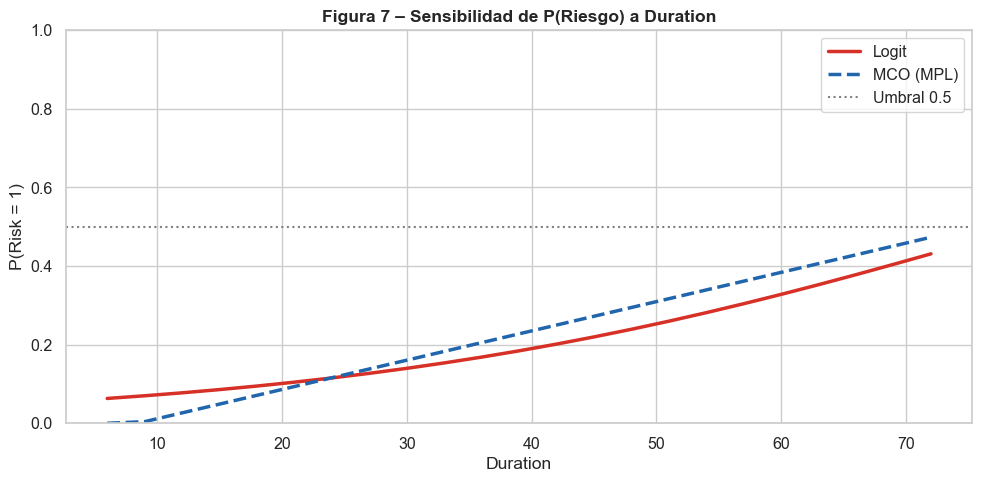

In [59]:
var_sens   = 'Duration'          # cambia por la que prefieras
rango_vals = np.arange(6, 73, 3) # rango lógico para meses

base = X_sel_const.iloc[[0]].copy()
sens_mco, sens_logit = [], []
for v in rango_vals:
    row = base.copy()
    row[var_sens] = v
    sens_mco.append(float(mco.predict(row).clip(0, 1)))
    sens_logit.append(float(logit_model.predict(row)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rango_vals, sens_logit, color='#d73027', lw=2.5, label='Logit')
ax.plot(rango_vals, sens_mco,   color='#2166ac', lw=2.5, ls='--', label='MCO (MPL)')
ax.axhline(0.5, color='gray', ls=':', lw=1.5, label='Umbral 0.5')
ax.set_xlabel(var_sens); ax.set_ylabel('P(Risk = 1)')
ax.set_title(f'Figura 7 – Sensibilidad de P(Riesgo) a {var_sens}', fontweight='bold')
ax.legend(); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

In [56]:
margins = logit_model.get_margeff()
print(margins.summary())


        Logit Marginal Effects       
Dep. Variable:                   Risk
Method:                          dydx
At:                           overall
                   dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Age              -0.0035      0.001     -2.719      0.007      -0.006      -0.001
Duration          0.0068      0.001      6.539      0.000       0.005       0.009
chk_num           0.0840      0.013      6.245      0.000       0.058       0.110
hous_num         -0.0535      0.020     -2.707      0.007      -0.092      -0.015
sex_bin          -0.0676      0.029     -2.311      0.021      -0.125      -0.010
purp_radio/TV    -0.0978      0.032     -3.034      0.002      -0.161      -0.035


In [57]:
acc_mco_val   = (((prob_mco_all := mco.predict(X_sel_const).clip(0,1)) >= 0.5).astype(int) == y).mean()
acc_logit_val = ((y_prob >= 0.5).astype(int) == y).mean()

resumen = pd.DataFrame({
    'Métrica' : ['R² / Pseudo-R² McFadden', 'AIC', 'BIC',
                 'AUC ROC', 'Accuracy (umbral=0.5)'],
    'MCO'     : [round(r2, 4), round(aic_mco, 2), round(mco.bic, 2),
                 'N/A', round(acc_mco_val, 4)],
    'Logit'   : [round(pseudo_r2, 4), round(aic_log, 2),
                 round(logit_model.bic, 2), round(roc_auc, 4),
                 round(acc_logit_val, 4)]
})
resumen


,Métrica,MCO,Logit
0,R² / Pseudo-R² McFadden,0.1106,0.0937
1,AIC,1174.06,1121.2900
2,BIC,1208.42,1155.6500
3,AUC ROC,N/A,0.7080
4,Accuracy (umbral=0.5),0.714,0.7110
